In [1]:
!pip install pandas==2.3.3
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 107.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
dopamine-rl 4

# DATA PREP

In [2]:
# ============================================================
# DATA PREP — PHYSIONET 2017 (DROP-IN REPLACEMENT)
# ============================================================

import os
import numpy as np
import pandas as pd
import wfdb
from collections import Counter
from scipy.signal import resample

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)

FS = 300
TARGET_FS = 300
SEG_LEN = 9000

ROOT_DIR = "/kaggle/input/physionet-af-dataset-modified/PhysioNet_AF_Dataset_modified/physionet.org/files/challenge-2017/1.0.0"
TRAIN_DIR = os.path.join(ROOT_DIR, "training")
VAL_DIR   = os.path.join(ROOT_DIR, "validation")
TRAIN_REF = os.path.join(TRAIN_DIR, "REFERENCE.csv")
VAL_REF   = os.path.join(VAL_DIR, "REFERENCE.csv")

def read_physionet_2017_records(base_dir, ref_csv):
    ref = pd.read_csv(ref_csv, header=None, names=["record", "label"])
    label_map = {"N": "N", "A": "A", "O": None, "~": None}

    Signals, Labels, Ids = [], [], []
    for _, row in ref.iterrows():
        rec = row["record"]
        lbl = label_map.get(row["label"])
        if lbl is None:
            continue
        try:
            record = wfdb.rdrecord(os.path.join(base_dir, rec))
            sig = record.p_signal[:, 0].astype(np.float32)
            sig = resample(sig, int(len(sig) * TARGET_FS / FS))
            if len(sig) >= SEG_LEN:
                Signals.append(sig)
                Labels.append(lbl)
                Ids.append(rec)
        except:
            continue
    return Signals, pd.Series(Labels, dtype="category"), np.array(Ids)

Signals_tr, Labels_tr, Ids_tr = read_physionet_2017_records(TRAIN_DIR, TRAIN_REF)
Signals_va, Labels_va, Ids_va = read_physionet_2017_records(VAL_DIR, VAL_REF)

Signals = Signals_tr + Signals_va
Labels  = pd.concat([Labels_tr, Labels_va], ignore_index=True)
Ids     = np.concatenate([Ids_tr, Ids_va])

records_df = pd.DataFrame({"id": Ids, "signal": Signals, "label": Labels})
print("Label distribution:", Counter(Labels))

train_ids, test_ids = train_test_split(
    records_df["id"].unique(), test_size=0.2, random_state=42
)

train_df = records_df[records_df["id"].isin(train_ids)].reset_index(drop=True)
test_df  = records_df[records_df["id"].isin(test_ids)].reset_index(drop=True)

def segment_signals_from_df(df, seg_len=SEG_LEN):
    X, Y = [], []
    for _, row in df.iterrows():
        x, y = row["signal"], row["label"]
        for i in range(len(x) // seg_len):
            X.append(x[i*seg_len:(i+1)*seg_len])
            Y.append(y)
    return X, Y

XTest, YTest = segment_signals_from_df(test_df)
le_test = LabelEncoder()
YTest_enc = le_test.fit_transform(YTest)

2026-02-02 07:46:31.056877: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770018391.517528      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770018391.652264      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770018392.810259      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770018392.810330      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770018392.810333      24 computation_placer.cc:177] computation placer alr

Label distribution: Counter({'N': 4686, 'A': 688})


# MODEL 1 — RAW ECG (RNN – REG + DROPOUT)

I0000 00:00:1770018550.510967      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770018550.517453      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/50


I0000 00:00:1770018558.320677      80 service.cc:152] XLA service 0x7ce2e0115dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770018558.320731      80 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770018558.320738      80 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770018559.344638      80 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1770018566.493020      80 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 194ms/step - accuracy: 0.5080 - loss: 1.0174
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.5297 - loss: 0.9230
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.5414 - loss: 0.8938
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.5611 - loss: 0.8551
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.5423 - loss: 0.8757
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.5648 - loss: 0.8382
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.5671 - loss: 0.8188
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.5923 - loss: 0.7874
Epoch 9/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.5951 - loss: 0.7761
Epoch 10/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.6000 - loss: 0.7696
Epoch 11/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.6016 - loss: 0.7690
Epoch 12/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accurac


RAW ECG RESULTS
ACC : 0.8915966386554622
PREC: 0.9577754891864058
REC : 0.9135559921414538
SPEC: 0.7616279069767442
F1  : 0.9351432880844646
Raw ECG model saved.


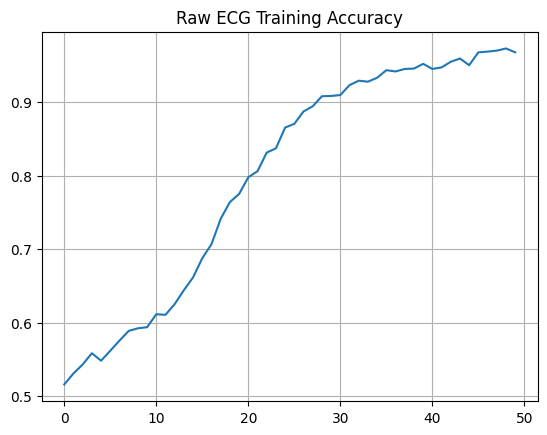

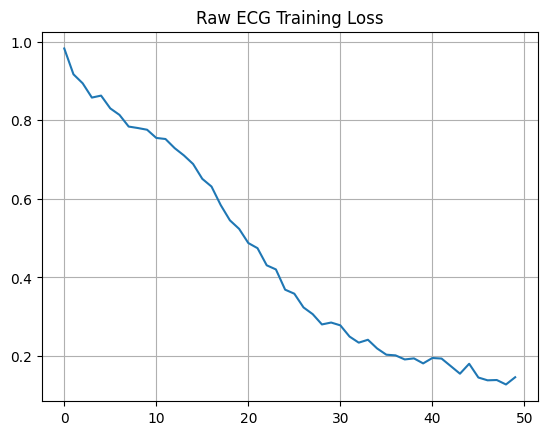

In [3]:
# ============================================================
# MODEL 1: RAW ECG + RNN — REG + DROPOUT
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils import resample
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, BatchNormalization,
    SimpleRNN, Dense, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

EPOCHS = 50
BATCH_SIZE = 128
WEIGHT_DECAY = 1e-4

def oversample(X, y):
    counter = Counter(y)
    max_count = max(counter.values())
    Xr, yr = [], []
    for cls in counter:
        Xc = [x for x, yy in zip(X, y) if yy == cls]
        yc = [cls]*len(Xc)
        Xu, yu = resample(Xc, yc, replace=True,
                          n_samples=max_count, random_state=42)
        Xr.extend(Xu); yr.extend(yu)
    return Xr, yr

def build_raw_ecg_model(input_shape):
    inp = Input(shape=input_shape)

    x = Conv1D(32, 7, strides=2, padding="same", kernel_regularizer=l2(WEIGHT_DECAY))(inp)
    x = BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = MaxPooling1D(2)(x)

    x = Conv1D(64, 5, strides=2, padding="same", kernel_regularizer=l2(WEIGHT_DECAY))(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = MaxPooling1D(2)(x)

    x = SimpleRNN(128, return_sequences=True,
                  kernel_regularizer=l2(WEIGHT_DECAY),
                  recurrent_regularizer=l2(WEIGHT_DECAY))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = SimpleRNN(64,
                  kernel_regularizer=l2(WEIGHT_DECAY),
                  recurrent_regularizer=l2(WEIGHT_DECAY))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(128, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)

    out = Dense(1, activation="sigmoid")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# -------- Data --------
Xtr, Ytr = segment_signals_from_df(train_df)
Xte, Yte = XTest, YTest

Xtr, Ytr = oversample(Xtr, Ytr)

mean = np.mean(np.concatenate(Xtr))
std  = np.std(np.concatenate(Xtr)) + 1e-8

Xtr = np.stack([(x-mean)/std for x in Xtr])[...,None]
Xte = np.stack([(x-mean)/std for x in Xte])[...,None]

le = LabelEncoder()
Ytr_enc = le.fit_transform(Ytr)
Yte_enc = le.transform(Yte)

tf.config.optimizer.set_jit(False)

# -------- Train --------
model_raw = build_raw_ecg_model(Xtr.shape[1:])
history = model_raw.fit(Xtr, Ytr_enc, epochs=EPOCHS,
                        batch_size=BATCH_SIZE, verbose=1)

# -------- Eval --------
y_prob_raw = model_raw.predict(Xte).ravel()
y_pred_raw = (y_prob_raw >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(Yte_enc, y_pred_raw).ravel()
print("\nRAW ECG RESULTS")
print("ACC :", accuracy_score(Yte_enc, y_pred_raw))
print("PREC:", precision_score(Yte_enc, y_pred_raw))
print("REC :", recall_score(Yte_enc, y_pred_raw))
print("SPEC:", tn/(tn+fp))
print("F1  :", f1_score(Yte_enc, y_pred_raw))

np.save("y_prob_raw.npy", y_prob_raw)
# Save RAW ECG model
model_raw.save("raw_ecg_rnn_reg_dropout.h5")
print("Raw ECG model saved.")

np.save("raw_mean.npy", mean)
np.save("raw_std.npy", std)

plt.plot(history.history["accuracy"]); plt.title("Raw ECG Training Accuracy"); plt.grid(); plt.show()
plt.plot(history.history["loss"]); plt.title("Raw ECG Training Loss"); plt.grid(); plt.show()